In [57]:
import torch
import torch.nn as nn
import pandas as pd
import networkx as nx
import numpy as np
import time
import torch.nn.functional as F

# Input the variables

In [3]:
Tum_dense = pd.read_csv('Tum_dense.csv')
tumor_id = pd.read_csv('tumor_id.csv')
immune_id = pd.read_csv('immune_id.csv')

# Helpers 

In [168]:
def initialize_location_matrix(params):
    file_path = params['file_path']
    index_file_path = params['index_file_path']
    height, width = 100, 100  # the cell grid shape is (100, 100)

    if file_path[-3:] == 'csv' and index_file_path[-3:] == 'csv':
        data = pd.read_csv(file_path)
        index_data = pd.read_csv(index_file_path)

        num_agents = len(index_data)

        tensor_list = []
        for agent_id in index_data['id']:
            data_tensor = torch.from_numpy(data.values).view(height, width)
            tensor_list.append(data_tensor)

        location_tensor = torch.stack(tensor_list, dim=0)
        assert location_tensor.shape == (num_agents, height, width), "Incorrect tensor shape"

        return location_tensor
    else:
        raise ValueError("Invalid file extensions. Expected CSV files.")

In [169]:
params = {  "file_path": 'Tum_dense.csv', "index_file_path":'tumor_id.csv'}
location_matrix = initialize_location_matrix(params)

In [171]:
print(location_matrix.shape)

torch.Size([10000, 100, 100])


# Observation functions

In [220]:
def CreateAdjacencyMatrix(location_matrix):
    num_agents, grid_height, grid_width = location_matrix.shape
    agent_adjacency_matrices = torch.zeros((num_agents, grid_height, grid_width), dtype=torch.float32)

    kernel = torch.tensor([ [0., 1., 0.],
                            [1., 0., 1.],
                            [0., 1., 0.]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    for agent_idx in range(num_agents):
        agent_density_tensor = location_matrix[agent_idx].float().unsqueeze(0).unsqueeze(0)
        conv_result = F.conv2d(agent_density_tensor, kernel, padding=1)
        agent_adjacency_matrices[agent_idx] = (conv_result.squeeze() > 0) & (agent_density_tensor.squeeze() == 0)

    return agent_adjacency_matrices

In [221]:
agent_adjacency_matrices = CreateAdjacencyMatrix(location_matrix)

In [222]:
agent_adjacency_matrices[0]

tensor([[1., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 1., 0., 0.]])

In [223]:
def ObserveFarNeighborhood(adjacency_matrix, Tum_dense, neighborhood_hops):
    num_agents = Tum_dense.shape[0]
    neighborhood_sum = torch.zeros((num_agents, Tum_dense.shape[1], Tum_dense.shape[2]), dtype=torch.long)

    for agent_idx in range(num_agents):
        agent_Tum_dense = Tum_dense[agent_idx].float()
        agent_adjacency_matrix = adjacency_matrix[agent_idx].float()
        
        agent_neighborhood_sum = torch.matmul((agent_adjacency_matrix**neighborhood_hops), agent_Tum_dense)
        neighborhood_sum[agent_idx] = agent_neighborhood_sum
    
    print("Tumor cell migration observation complete!")
    return neighborhood_sum

In [224]:
neighborhood_sum = ObserveFarNeighborhood(agent_adjacency_matrices, location_matrix, 2)

Tumor cell migration observation complete!


In [225]:
print(neighborhood_sum[0])

tensor([[18, 18, 14,  ..., 22, 22, 21],
        [10,  5,  9,  ..., 10,  9, 10],
        [10,  7, 10,  ..., 10, 10, 10],
        ...,
        [12,  7, 12,  ..., 12, 12, 12],
        [ 8,  3,  8,  ...,  8,  8,  8],
        [15, 15, 15,  ..., 15, 15,  9]])


# Decision or Policy function

In [247]:
def _get_nature(TUpmig):
        return 1 if torch.bernoulli(torch.tensor(TUpmig)) else 0

def MigrationTUDecision(new_neighborhood, initial_neighborhood):
    TUpmig = 0.35
    nature = _get_nature(TUpmig)
    actions = new_neighborhood if nature == 1 else initial_neighborhood

    print("tumor migration decision taken!")
    return actions

In [267]:
action = MigrationTUDecision(neighborhood_sum, location_matrix)

tumor migration decision taken!


In [268]:
print(action[0])

tensor([[18, 18, 14,  ..., 22, 22, 21],
        [10,  5,  9,  ..., 10,  9, 10],
        [10,  7, 10,  ..., 10, 10, 10],
        ...,
        [12,  7, 12,  ..., 12, 12, 12],
        [ 8,  3,  8,  ...,  8,  8,  8],
        [15, 15, 15,  ..., 15, 15,  9]])


# Transition function

In [296]:
def MigrateTUCell(location_matrix, action):
    migrate_action = action
    old_tu_x, old_tu_y = torch.where(location_matrix[0] == 1)
    new_tu_x, new_tu_y = torch.where(migrate_action[0] == 0)

    def migrate_cell(matrix, new_tu_x, new_tu_y, old_tu_x, old_tu_y):
        matrix[new_tu_x, new_tu_y] = 1
        matrix[old_tu_x, old_tu_y] = 0
        return matrix

    # define the function to migrate the cell
    updated_location_matrix = torch.vmap(migrate_cell, in_dims=(0, None, None, None, None))(
        location_matrix,  # matrix
        new_tu_x, new_tu_y,  # new loc
        old_tu_x, old_tu_y)  # old loc

    print("location_matrix: ", location_matrix.shape)
    print("migrate_action: ", migrate_action.shape)
    print("updated_location_matrix: ", updated_location_matrix.shape)
    print("tumor cell migration transition complete!")

    return updated_location_matrix

In [297]:
updated_location_matrix = MigrateTUCell(location_matrix, action)

location_matrix:  torch.Size([10000, 100, 100])
migrate_action:  torch.Size([10000, 100, 100])
updated_location_matrix:  torch.Size([10000, 100, 100])
tumor cell migration transition complete!


# Analysis

In [276]:
# #  Plot the output of each step one by one

import matplotlib.pyplot as plt

# plt.imshow(location_matrix[0])
# plt.title("Initial location matrix")
# plt.show()

# plt.imshow(agent_adjacency_matrices[0])
# plt.title("Agent adjacency matrix")
# plt.show()

# plt.imshow(neighborhood_sum[0])
# plt.title("Neighborhood sum")
# plt.show()

# plt.imshow(action[0])
# plt.title("Migration action")
# plt.show()

# plt.imshow(updated_location_matrix[0])
# plt.title("Updated location matrix")
# plt.show()


(100, 100)


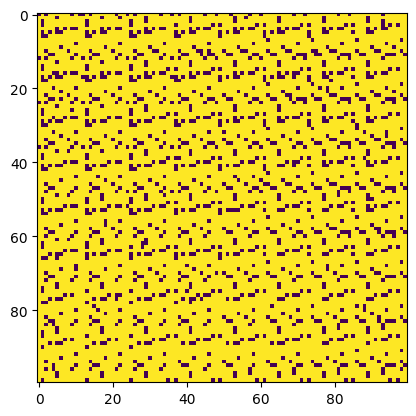

In [277]:
tum_tensor = Tum_dense.values.reshape(100, 100)
print(tum_tensor.shape)
plt.imshow(tum_tensor)

In [282]:
print("difference: ", torch.sum(updated_location_matrix - location_matrix))

difference:  tensor(0)


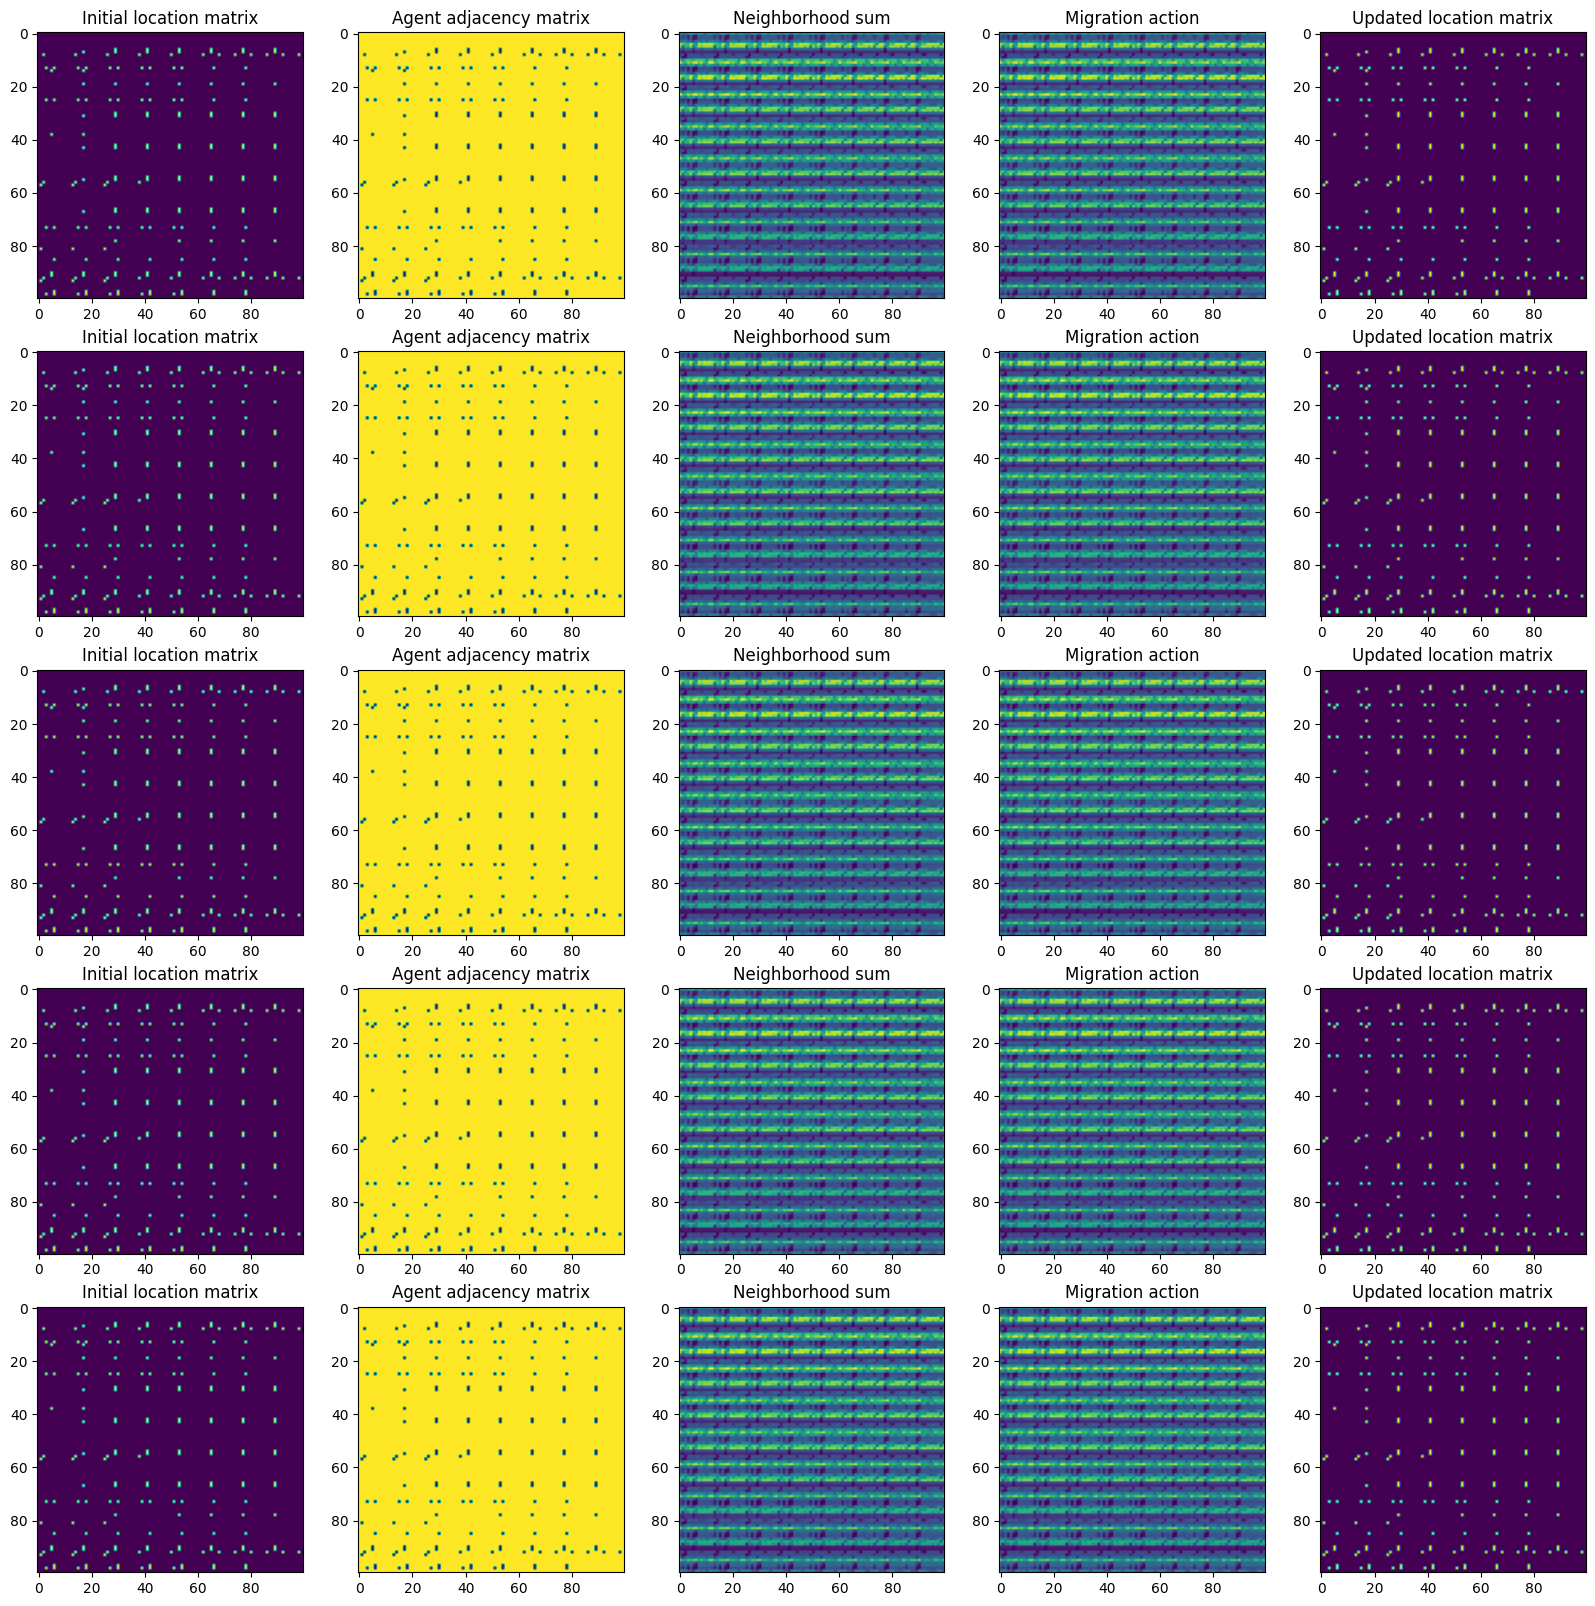

In [283]:

#  Plot the output of each step in a single figure
# do this for at least 5 agents

fig, axs = plt.subplots(5, 5, figsize=(20, 20))
for i in range(5):
    axs[i, 0].imshow(location_matrix[i])
    axs[i, 0].set_title("Initial location matrix")
    axs[i, 1].imshow(agent_adjacency_matrices[i])
    axs[i, 1].set_title("Agent adjacency matrix")
    axs[i, 2].imshow(neighborhood_sum[i])
    axs[i, 2].set_title("Neighborhood sum")
    axs[i, 3].imshow(action[i])
    axs[i, 3].set_title("Migration action")
    axs[i, 4].imshow(updated_location_matrix[i])
    axs[i, 4].set_title("Updated location matrix")